In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1 — Introduction

The goal of this project is to build a **machine learning** model that predicts the market price of cars based on their characteristics.

We will follow a complete machine learning workflow using the **K-Nearest Neighbors** (`KNN`) regression algorithm.

## Objectives

In this first step, we will:

1. Load the automobile dataset.
2. Assign the correct column names.
3. Identify the *numeric* columns that can be used as **features**.
4. Remove columns that cannot be directly used by `KNN`.
5. Handle missing values.
6. Separate the features (`X`) from the target (`y`).

In [ ]:
cars = pd.read_csv(
    r"E:\project_DS\Predicting Car Prices\automobile\imports-85.data",
    header=None,
    na_values="?"
)



# Loading and Naming the Dataset

The raw dataset does not contain column names. Therefore, we:

* Assign the column names provided in the dataset documentation.
* Use `snake_case` naming to make the columns easier to work with in `Python`.

In [68]:
cars.columns = [
    "symboling",
    "normalized_losses",
    "make",
    "fuel_type",
    "aspiration",
    "num_doors",
    "body_style",
    "drive_wheels",
    "engine_location",
    "wheel_base",
    "length",
    "width",
    "height",
    "curb_weight",
    "engine_type",
    "num_cylinders",
    "engine_size",
    "fuel_system",
    "bore",
    "stroke",
    "compression_ratio",
    "horsepower",
    "peak_rpm",
    "city_mpg",
    "highway_mpg",
    "price"
]

# Selecting Numeric Features

**K-Nearest Neighbors** is a *distance-based* algorithm, so the features used by the model need to be numeric.

## Feature Selection

* We select the numeric columns from the dataset.
* We exclude categorical variables such as `make`, `fuel_type`, and `body_style`.
* The `price` column is numeric as well, but it is the **target variable** rather than an input feature.

In [27]:
numeric_columns = cars.select_dtypes(include="number").columns

numeric_columns


Index(['symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
       'height', 'curb_weight', 'engine_size', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='object')

In [28]:
cars.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


# Handling Missing Values

The dataset contains missing values represented by `NaN`.

## Data Cleaning

* We remove rows with missing values from the numeric dataset, as specifically requested by the project instructions.
* This gives us a complete dataset that can be used by the `KNN` algorithm without requiring additional *imputation*.

In [29]:
cars.dropna(inplace=True)


In [30]:
cars.isnull().sum()


symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_doors            0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_cylinders        0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

In [31]:
cars.head()


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500.0,18,22,17450.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110.0,5500.0,19,25,17710.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140.0,5500.0,17,20,23875.0
10,2,192.0,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.8,8.8,101.0,5800.0,23,29,16430.0


In [33]:
x = cars.drop("price", axis=1)
y = cars["price"]


In [35]:
x.shape, y.shape


((159, 25), (159,))

# Step 2 — Examining Relationships Between Predictors

Before training the `KNN` model, we examine the relationships between the numeric predictors.

## Understanding the Features

* Because `KNN` relies on *distances* between observations, understanding the relationships and distributions of the predictors can help us identify potentially redundant or strongly related variables.
* We use **correlation** to measure the linear relationship between numeric variables.

In [43]:
correlation_matrix = cars.corr(numeric_only=True)


# Visualizing Correlations

A **correlation matrix** can be difficult to interpret when there are many variables.

## Visualization Approach

* We therefore visualize the matrix using a **heatmap** so that strong *positive* and *negative* relationships can be identified more easily.

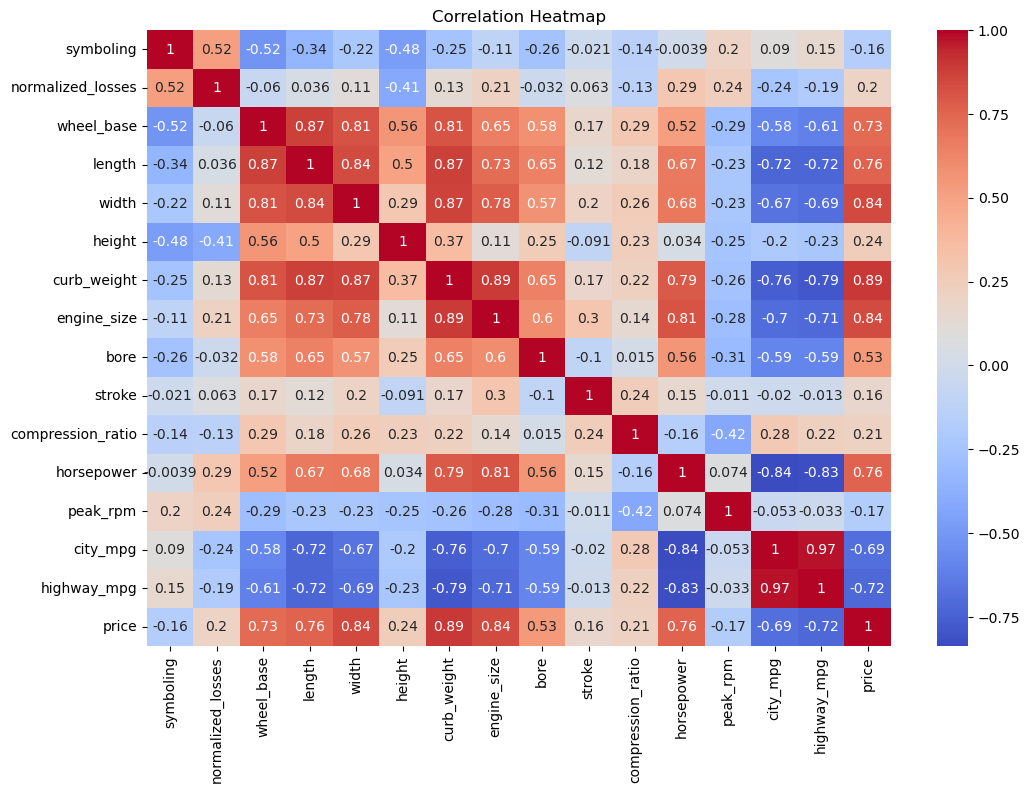

In [44]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

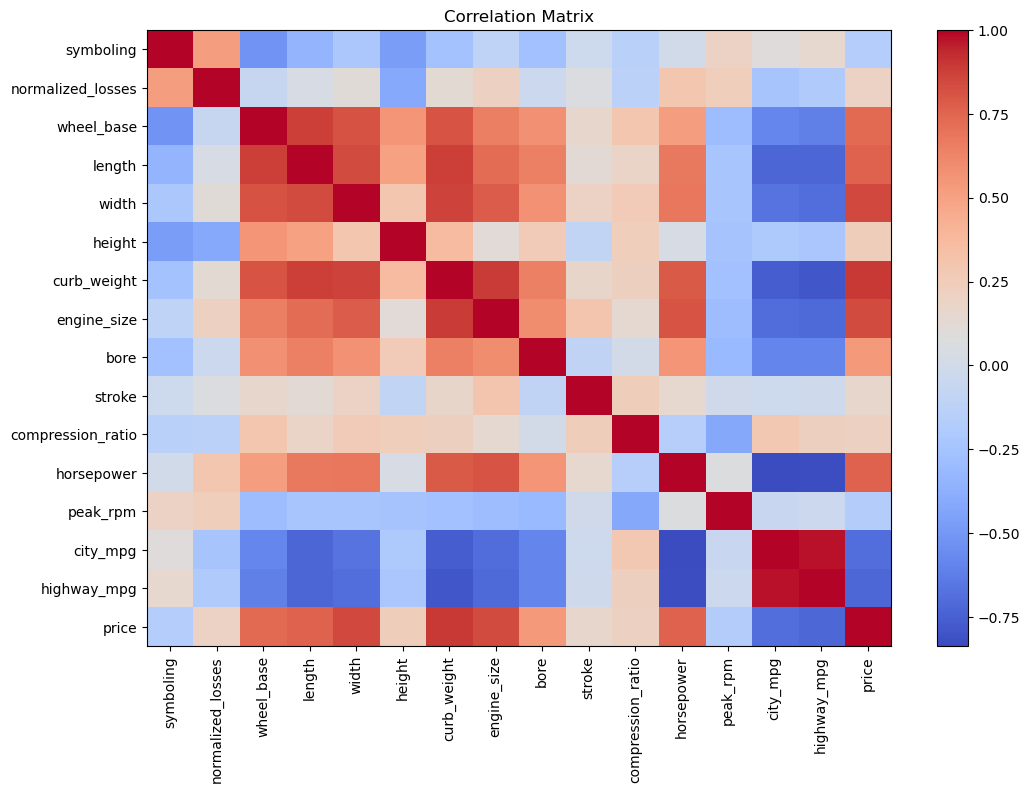

In [45]:


plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix")
plt.show()


# Step 3 — Setting Up the Train-Test Split

To evaluate how well the model generalizes to unseen data, we split the dataset into training and test sets.

## Splitting Strategy

* The **training set** will be used to build and optimize the model.
* The **test set** will remain *unseen* until the final evaluation.
* We use **80%** of the data for training and **20%** for testing.

In [51]:
numeric_columns = cars.select_dtypes(include="number").columns

x = cars[numeric_columns].drop(columns="price")
y = cars["price"]


from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)




# Feature Scaling

`KNN` calculates *distances* between observations. Therefore, features with larger numerical ranges can have a greater influence on the distance calculation.

## Standardization Process

To prevent this, we standardize the features using `StandardScaler`.

1. The scaler is fitted **only** on the training data to avoid data leakage.
2. The same fitted scaler is then used to transform the test data.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# Step 4 — Cross-validation and Hyperparameter Optimization

The `KNN` algorithm requires us to choose the number of neighbors, represented by `K`.

## Optimization Strategy

* Instead of choosing `K` arbitrarily, we use *k-fold cross-validation* on the training data to evaluate multiple values of `K`.
* We use `GridSearchCV` to test different values of `K` and select the one that gives the **best** cross-validation performance.

In [53]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": range(1, 21)
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_search.fit(x_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': range(1, 21)},
             scoring='neg_mean_squared_error')

# Selecting the Best K

We examine the cross-validation results to determine which value of `K` provides the lowest **Mean Squared Error**.

## Evaluating Performance

* Because `Scikit-learn` maximizes scoring metrics, **Mean Squared Error** is represented as a negative value (*negative MSE*).
* Therefore, a value closer to zero indicates better performance.

In [54]:
grid_search.best_params_


{'n_neighbors': 1}

In [55]:
grid_search.best_score_


-8765688.624

In [57]:
mse = -grid_search.best_score_
print(f"mean squared error: {mse}")

rmse = np.sqrt(-grid_search.best_score_)
print(f"root mean squared error: {rmse}")


mean squared error: 8765688.624
root mean squared error: 2960.690565391797


# Step 5 — Experimenting With Different Models

To understand how the number of neighbors affects the `KNN` model, we examine the cross-validation performance for different values of `K`.

## The Impact of K

* A *small* value of `K` can make the model sensitive to individual observations and noise.
* A *large* value of `K` produces a smoother model that may **underfit** the data.
* We therefore compare the performance across different values of `K`.

In [58]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    ["param_n_neighbors", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)


,param_n_neighbors,mean_test_score,std_test_score
0,1,-8.765689e+06,4.850942e+06
1,2,-9.481130e+06,4.671387e+06
3,4,-9.505308e+06,3.496687e+06
4,5,-9.893207e+06,3.515483e+06
6,7,-1.035763e+07,4.677764e+06
5,6,-1.044584e+07,4.238692e+06
2,3,-1.048658e+07,4.370098e+06
7,8,-1.062451e+07,4.714314e+06
8,9,-1.063297e+07,4.421260e+06
9,10,-1.140199e+07,4.599470e+06


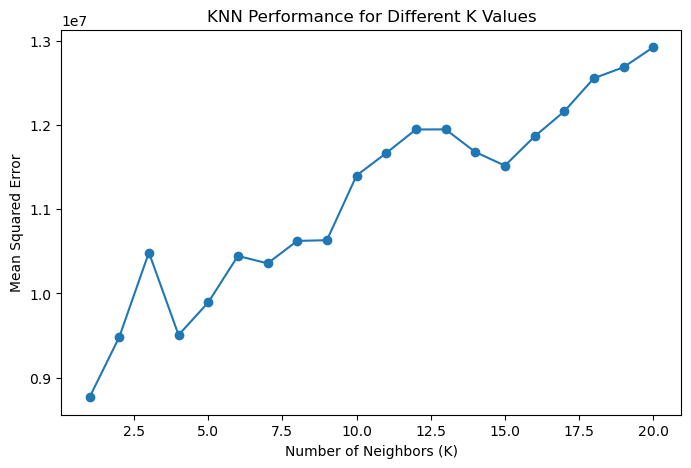

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    results["param_n_neighbors"],
    -results["mean_test_score"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Squared Error")
plt.title("KNN Performance for Different K Values")
plt.show()


# Step 6 — Final Model Evaluation

After selecting the best value of `K` using *cross-validation*, we evaluate the final model on the **test set**.

## Test Set Evaluation

* The **test set** contains observations that were not used during model training or hyperparameter selection.
* We use **Mean Squared Error** (`MSE`), **Root Mean Squared Error** (`RMSE`), **Mean Absolute Error** (`MAE`), and `R²` to evaluate the model.

In [61]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)


In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


MSE: 5830649.625
RMSE: 2414.6738133752146
MAE: 1725.25
R²: 0.672336563916149


# Interpreting the Results

The final model achieved an `R²` score of approximately **0.67** on the test set, indicating that the model explains a substantial portion of the variation in car prices.

## Metric Analysis

* The `MAE` indicates the average absolute prediction error in the same units as the target variable.
* The `RMSE` gives more weight to larger prediction errors.
* The test performance should be interpreted alongside the *cross-validation* results to understand how well the model generalizes to unseen data.

# Step 7 — Next Steps

Although the `KNN` model provides a reasonable baseline, there are several ways the analysis could be improved.

## Possible Improvements

* Testing different preprocessing and scaling strategies.
* Investigating different approaches for handling missing values, such as *imputation*.
* Performing **feature selection** to determine whether all predictors contribute useful information.
* Testing additional **regression algorithms** and comparing their performance with `KNN`.
* Using additional *validation strategies* to assess the stability of the model.
* Performing more extensive **hyperparameter tuning**.

These experiments could help determine whether `KNN` is the most appropriate algorithm for predicting car prices and potentially improve the model's *generalization performance*.

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

param_grid = {
    "knn__n_neighbors": range(1, 21)
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_search.fit(x_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsRegressor())]),
             param_grid={'knn__n_neighbors': range(1, 21)},
             scoring='neg_mean_squared_error')

In [64]:
print(grid_search.best_params_)
print(-grid_search.best_score_)


{'knn__n_neighbors': 1}
8839290.477846153


In [65]:
y_pred = grid_search.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


MSE: 5830649.625
RMSE: 2414.6738133752146
MAE: 1725.25
R²: 0.672336563916149


In [66]:
grid_search.best_params_


{'knn__n_neighbors': 1}

In [67]:
grid_search.best_score_


-8839290.477846153